In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

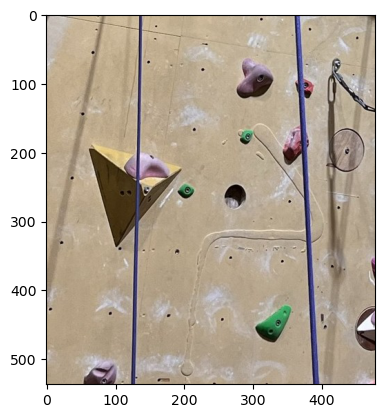

In [51]:
image = cv2.imread('../data/crop.jpg')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

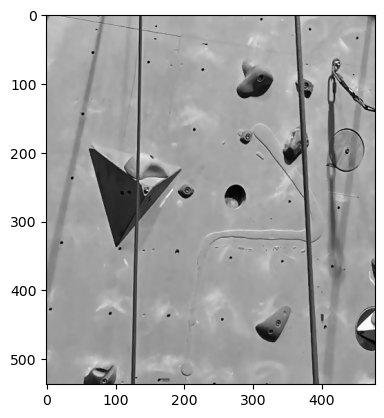

In [52]:
bilateral = cv2.bilateralFilter(image, 9, 50, 50)  
# converting to grayscale before bilateral filtering makes the computer colorblind,
# causing it to blur edges that should be distinct -> therefore filter is applied on rgb
bilateral_rgb = cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB) 
bil_gray_image = cv2.cvtColor(bilateral_rgb, cv2.COLOR_BGR2GRAY)

plt.imshow(bil_gray_image, cmap="gray")

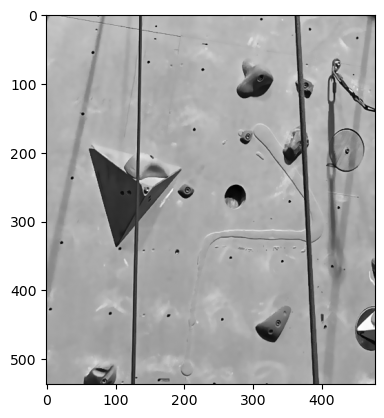

In [53]:
bil_gray_image = cv2.cvtColor(bilateral, cv2.COLOR_BGR2GRAY)

plt.imshow(bil_gray_image, cmap="gray")

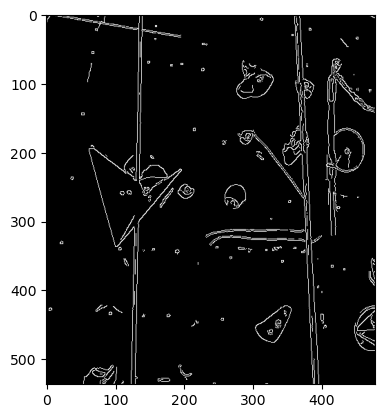

In [40]:
edges_canny = cv2.Canny(bil_gray_image, 100, 200)

plt.imshow(edges_canny, cmap='gray')

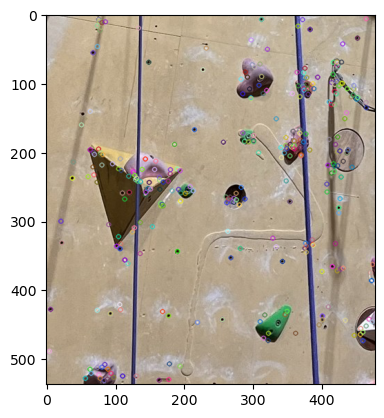

In [41]:
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(bil_gray_image, None)
image_with_sift = cv2.drawKeypoints(image, keypoints, None)

plt.imshow(cv2.cvtColor(image_with_sift, cv2.COLOR_BGR2RGB))

Found 41 circles.


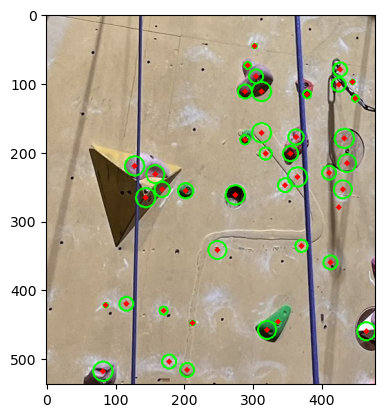

In [61]:
circles = cv2.HoughCircles(
    bil_gray_image, 
    cv2.HOUGH_GRADIENT, # comments: accurate version for my initial photos: 1,15,50,6,1,3
    dp=1,           # 1
    minDist=20,     # 15
    param1=50,      # Edge sensitivity 50
    param2=12,       # 6
    minRadius=1,    # 1
    maxRadius=15     # 3
)

# 3. Quick Check
if circles is not None:
    print(f"Found {len(circles[0])} circles.")
    
    # Draw them to verify
    output = image.copy()
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        cv2.circle(output, (i[0], i[1]), i[2], (0, 255, 0), 2)
        cv2.circle(output, (i[0], i[1]), 2, (0, 0, 255), 3)
    
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.show()
else:
    print("No circles found. Try lowering param2.")

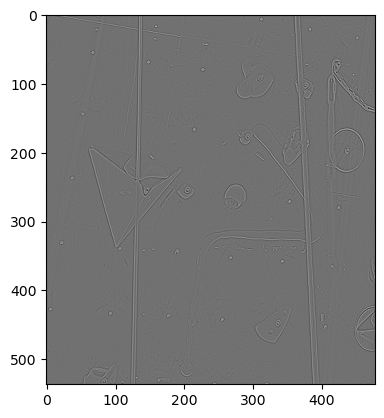

In [24]:
laplacian = cv2.Laplacian(gray_image,cv2.CV_64F)

plt.imshow(laplacian, cmap='gray')

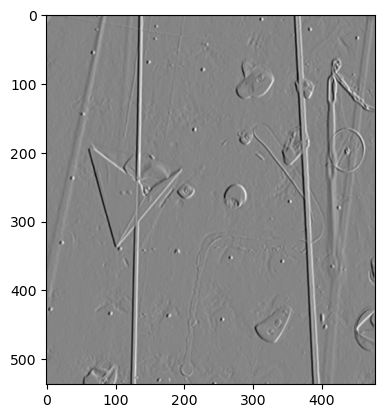

In [25]:
sobelx = cv2.Sobel(src=gray_image, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=5) # Sobel Edge Detection on the X axis

plt.imshow(sobelx, cmap='gray')

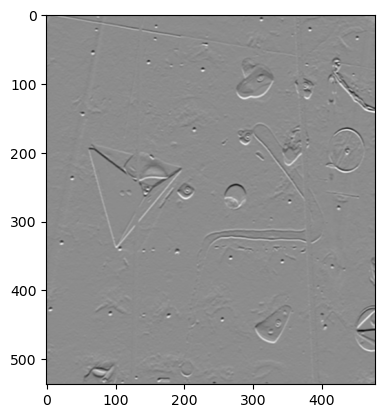

In [26]:
sobely = cv2.Sobel(src=gray_image, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=5) # Sobel Edge Detection on the Y axis

plt.imshow(sobely, cmap='gray')

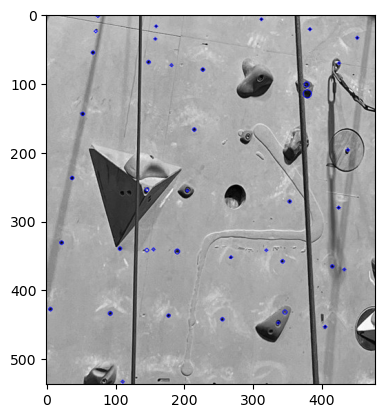

In [27]:
params = cv2.SimpleBlobDetector_Params()

params.filterByArea = True
params.minArea = 10   
params.maxArea = 300

params.filterByCircularity = True
params.minCircularity = 0.6

params.filterByConvexity = True
params.minConvexity = 0.87

params.filterByInertia = True
params.minInertiaRatio = 0.5

detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(gray_image)

output = cv2.drawKeypoints(
    gray_image,
    keypoints,
    None,
    (0, 0, 255),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)
plt.imshow(output, cmap='gray')

In [28]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

bilateral = cv2.bilateralFilter(image, 9, 50, 50)  
# converting to grayscale before bilateral filtering makes the computer colorblind,
# causing it to blur edges that should be distinct -> therefore filter is applied on rgb
bilateral_rgb = cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB) 
bil_gray_image = cv2.cvtColor(bilateral_rgb, cv2.COLOR_BGR2GRAY)

edges_canny = cv2.Canny(bil_gray_image, 100, 200)

sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(bil_gray_image, None)
image_with_sift = cv2.drawKeypoints(image, keypoints, None)

circles = cv2.HoughCircles(
    bil_gray_image, 
    cv2.HOUGH_GRADIENT, # comments: accurate version for my initial photos: 1,15,50,6,1,3
    dp=1,           # 1
    minDist=10,     # 15
    param1=40,      # Edge sensitivity 50
    param2=8,       # 6
    minRadius=1,    # 1
    maxRadius=15     # 3
)

laplacian = cv2.Laplacian(gray_image,cv2.CV_64F)

sobelx = cv2.Sobel(src=gray_image, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=5) # Sobel Edge Detection on the X axis

sobely = cv2.Sobel(src=gray_image, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=5) # Sobel Edge Detection on the Y axis

params = cv2.SimpleBlobDetector_Params()

params.filterByArea = True
params.minArea = 10   
params.maxArea = 300

params.filterByCircularity = True
params.minCircularity = 0.6

params.filterByConvexity = True
params.minConvexity = 0.87

params.filterByInertia = True
params.minInertiaRatio = 0.5

detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(gray_image)

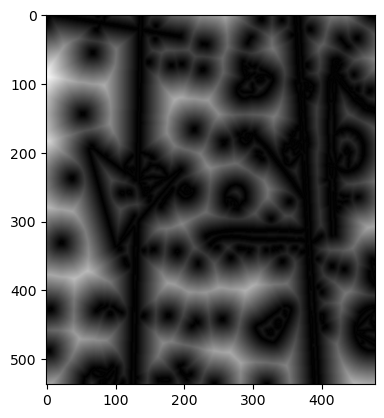

In [31]:
edges_inverted = cv2.bitwise_not(edges_canny)

# Calculate Distance to the nearest Zero (Black) pixel
dist_transform = cv2.distanceTransform(edges_inverted, cv2.DIST_L2, 5)

dist_transform = cv2.normalize(dist_transform, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

plt.imshow(dist_transform, cmap='gray')